In [1]:
import pandas as pd
import datetime as dt
from matplotlib import pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
def replace_timestamps_with_step_times(df):
    step_names = ["prefetch", "fasterq_dump", "salmon", "deseq2_salmon", "star", "deseq2_star"]
    for step_name in step_names:
        if step_name+"_start_time" in df.columns:
            start_times = (pd.to_datetime(df[f"{step_name}_start_time"]) - dt.datetime(1970,1,1)).dt.total_seconds()
            end_times = (pd.to_datetime(df[f"{step_name}_end_time"]) - dt.datetime(1970,1,1)).dt.total_seconds()
            df[f"{step_name} [s]"] = end_times - start_times

    return df

In [3]:
df_AMD = replace_timestamps_with_step_times(pd.read_csv("data/r7a_2xlarge.csv", index_col=0))
df_ARM = replace_timestamps_with_step_times(pd.read_csv("data/r8g_2xlarge.csv", index_col=0))

In [4]:
df_AMD = df_AMD[df_AMD["SRR_id"].isin(set(df_ARM["SRR_id"]))]

In [5]:
df_prices = pd.DataFrame(data={"price_per_h": [0.6086, 0.4713]}, index=["r7a.2xlarge", "r8g.2xlarge"])

In [6]:
total_time_AMD_h = ((df_AMD['star [s]'] + df_AMD['prefetch [s]'] + df_AMD['fasterq_dump [s]'] + df_AMD['deseq2_star [s]']).sum() / 3600)
total_time_ARM_h = ((df_ARM['star [s]'] + df_ARM['prefetch [s]'] + df_ARM['fasterq_dump [s]'] + df_ARM['deseq2_star [s]']).sum() / 3600)

total_STAR_time_AMD_h = df_AMD['star [s]'].sum() / 3600
total_STAR_time_ARM_h = df_ARM['star [s]'].sum() / 3600

In [7]:
print(f"R7a total pipeline execution time: {total_time_AMD_h:.2f} h")
print(f"R8g total pipeline execution time: {total_time_ARM_h:.2f} h")

R7a total pipeline execution time: 7.33 h
R8g total pipeline execution time: 6.99 h


In [8]:
print(f"R7a total pipeline cost: {(total_time_AMD_h * df_prices.loc['r7a.2xlarge', 'price_per_h']):.2f} h")
print(f"R8g total pipeline cost: {(total_time_ARM_h * df_prices.loc['r8g.2xlarge', 'price_per_h']):.2f} h")

R7a total pipeline cost: 4.46 h
R8g total pipeline cost: 3.29 h


In [9]:
print(f"R7a.2xlarge STAR total cost: {(total_STAR_time_AMD_h * df_prices.loc['r7a.2xlarge', 'price_per_h']):.2f} $")
print(f"R8g.2xlarge STAR total cost: {(total_STAR_time_ARM_h * df_prices.loc['r8g.2xlarge', 'price_per_h']):.2f} $")

R7a.2xlarge STAR total cost: 3.33 $
R8g.2xlarge STAR total cost: 2.31 $


In [10]:
print(f"R7a total STAR execution time: {total_STAR_time_AMD_h:.2f} h")
print(f"R8g total STAR execution time: {total_STAR_time_ARM_h:.2f} h")

R7a total STAR execution time: 5.48 h
R8g total STAR execution time: 4.91 h


In [11]:
print(f"R7a mean STAR execution time: {(df_AMD['star [s]'].mean()):.2f} s")
print(f"R8g mean STAR execution time: {(df_ARM['star [s]'].mean()):.2f} s")

R7a mean STAR execution time: 394.30 s
R8g mean STAR execution time: 353.24 s


In [12]:
def non_star_steps_percent(df):
    return ((df["prefetch [s]"] + df["fasterq_dump [s]"] + df["deseq2_star [s]"]) / (df["prefetch [s]"] + df["fasterq_dump [s]"] + df["star [s]"] + df["deseq2_star [s]"])).mean()

print(f"R7a non-STAR steps total execution time percent : {non_star_steps_percent(df_AMD):.2f} %")
print(f"R8g non-STAR steps total execution time percent : {non_star_steps_percent(df_ARM):.2f} %")

R7a non-STAR steps total execution time percent : 0.31 %
R8g non-STAR steps total execution time percent : 0.34 %


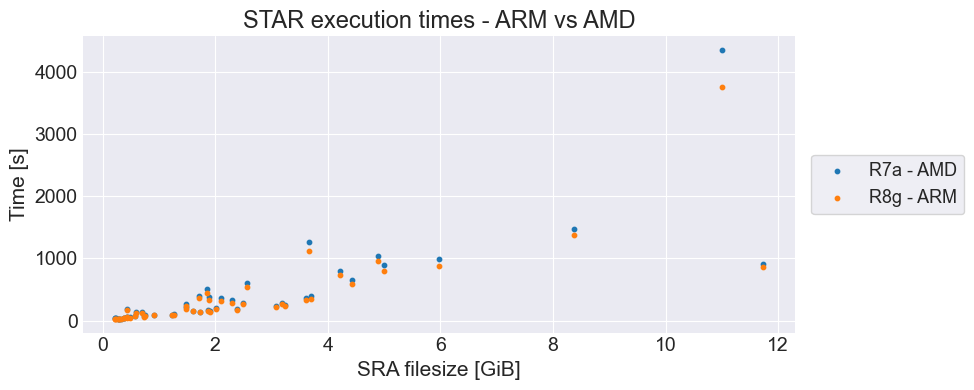

In [13]:
fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

ax.scatter(df_AMD['SRR_filesize_bytes'] / 1024**3, df_AMD['star [s]'], label='R7a - AMD', s=10)
ax.scatter(df_ARM['SRR_filesize_bytes'] / 1024**3, df_ARM['star [s]'], label='R8g - ARM', s=10)

ax.set_xlabel('SRA filesize [GiB]', fontsize=15)
ax.set_ylabel('Time [s]', fontsize=15)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_title('STAR execution times - ARM vs AMD', fontsize=17)

ax.legend(fontsize=13, bbox_to_anchor=(1.25, 0.5), frameon=True, loc='center right')
plt.tight_layout()
plt.savefig('plots/STAR_exec_times_ARM_vs_AMD.pdf', bbox_inches='tight')
plt.show()